In [1]:
import numpy as np
import pandas as pd
import missingno
pd.set_option('display.max_columns', None)

enc = 'utf-8'

In [2]:
base_folder = 'E:/Drive/NOA/MBD-Prediction/NUTS3 - Level/Greece/data/'

In [3]:
NUTS2 = 'Thessaly'
YEAR = '2024'

In [4]:
data = pd.read_csv(f'{base_folder}/{NUTS2}/GR_{NUTS2}_Timeline_NUTS3_{YEAR}_filled.csv', encoding=enc)

In [5]:
try:
    data.drop(columns=['Unnamed: 0'], inplace=True)
except Exception:
    print("No column named \'Unnamed: 0\'")

In [6]:
try:
    data.drop(columns=['Unnamed: 0.1'], inplace=True)
except Exception:
    print("No column named \'Unnamed: 0\'")

No column named 'Unnamed: 0'


<Axes: >

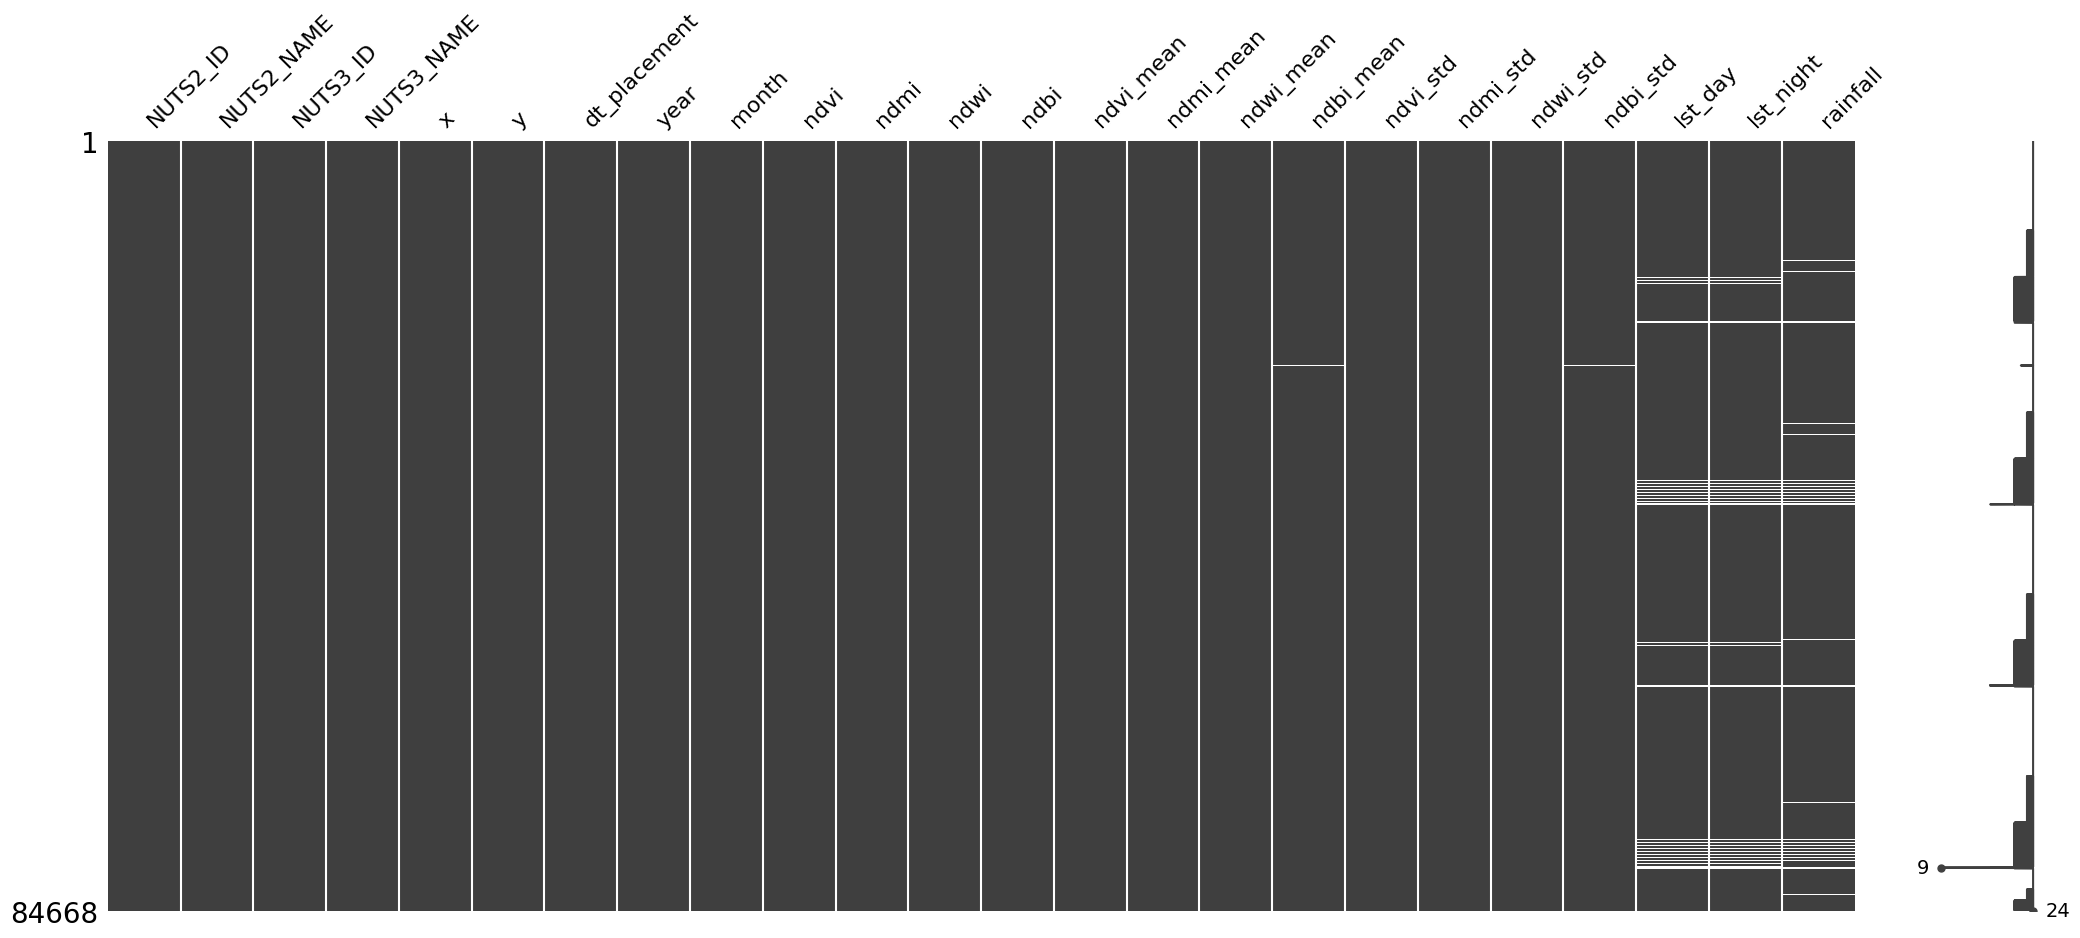

In [7]:
missingno.matrix(data)

In [8]:
data.dtypes

NUTS2_ID         object
NUTS2_NAME       object
NUTS3_ID         object
NUTS3_NAME       object
x               float64
y               float64
dt_placement     object
year              int64
month             int64
ndvi            float64
ndmi            float64
ndwi            float64
ndbi            float64
ndvi_mean       float64
ndmi_mean       float64
ndwi_mean       float64
ndbi_mean       float64
ndvi_std        float64
ndmi_std        float64
ndwi_std        float64
ndbi_std        float64
lst_day         float64
lst_night       float64
rainfall        float64
dtype: object

In [9]:
# data.lst_day.unique()

In [10]:
# data['lst_day'] = data['lst_day'].replace(r'\b\d{4}-\d{2}-\d{2}\b', np.nan, regex=True)

In [11]:
# data['lst_day'] = data['lst_day'].astype(float)

In [12]:
# data.drop(columns=['rainfall.1'], inplace=True)

In [13]:
data['dt_placement'] = pd.to_datetime(data['dt_placement'])

# Extract year, month, and day from the 'date' column
data['year'] = data['dt_placement'].dt.year
data['month'] = data['dt_placement'].dt.month
data['day'] = data['dt_placement'].dt.day

In [14]:
data

,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,dt_placement,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall,day
0,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",21.19021,39.65516,2024-01-01,2024,1,0.473835,0.142222,-0.420871,-0.142222,0.388692,0.274328,-0.303196,-0.274328,0.140335,0.143803,0.112971,0.143803,13814.0,13689.0,1.164514,1
1,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",21.19021,39.65516,2024-01-02,2024,1,0.473835,0.142222,-0.420871,-0.142222,0.388692,0.274328,-0.303196,-0.274328,0.140335,0.143803,0.112971,0.143803,13814.0,13712.0,11.846938,2
2,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",21.19021,39.65516,2024-01-03,2024,1,0.473835,0.142222,-0.420871,-0.142222,0.388692,0.274328,-0.303196,-0.274328,0.140335,0.143803,0.112971,0.143803,13814.0,13712.0,0.714449,3
3,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",21.19021,39.65516,2024-01-04,2024,1,0.473835,0.142222,-0.420871,-0.142222,0.388692,0.274328,-0.303196,-0.274328,0.140335,0.143803,0.112971,0.143803,13814.0,13834.0,0.000000,4
4,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",21.19021,39.65516,2024-01-05,2024,1,0.473835,0.142222,-0.420871,-0.142222,0.388692,0.274328,-0.303196,-0.274328,0.140335,0.143803,0.112971,0.143803,13854.0,13678.0,0.250432,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
84663,EL61,θεσσαλια,EL613,"μαγνησια, σποραδες",22.74624,39.31112,2024-05-01,2024,5,0.657875,0.377295,-0.567324,-0.377295,0.533775,0.229863,-0.484205,-0.229863,0.091889,0.106971,0.061969,0.106971,NaN,NaN,NaN,1
84664,EL61,θεσσαλια,EL613,"μαγνησια, σποραδες",22.74624,39.27518,2024-05-01,2024,5,0.377570,0.176377,-0.317248,-0.176377,0.412067,0.206542,-0.339813,-0.206542,0.041501,0.030382,0.038669,0.030382,NaN,NaN,NaN,1
84665,EL61,θεσσαλια,EL613,"μαγνησια, σποραδες",22.74624,39.23925,2024-05-01,2024,5,0.318741,0.115418,-0.321000,-0.115418,0.357992,0.105538,-0.354827,-0.105538,0.111367,0.083026,0.085742,0.083026,NaN,NaN,NaN,1
84666,EL61,θεσσαλια,EL613,"μαγνησια, σποραδες",22.74624,39.16738,2024-05-01,2024,5,0.377635,0.153777,-0.372142,-0.153777,0.344275,0.125509,-0.362614,-0.125509,0.035156,0.029671,0.018951,0.029671,NaN,NaN,NaN,1


In [15]:
data_jan = data.loc[data['month'] == 1]
data_fed = data.loc[data['month'] == 2]
data_mar = data.loc[data['month'] == 3]
data_apr = data.loc[data['month'] == 4]

In [16]:
df_mean_jan = data_jan.groupby(['NUTS3_ID', 'year', 'month'], as_index=False)[['lst_day', 'lst_night']].mean()
df_mean_feb = data_fed.groupby(['NUTS3_ID', 'year', 'month'], as_index=False)[['lst_day', 'lst_night']].mean()
df_mean_mar = data_mar.groupby(['NUTS3_ID', 'year', 'month'], as_index=False)[['lst_day', 'lst_night']].mean()
df_mean_apr = data_apr.groupby(['NUTS3_ID', 'year', 'month'], as_index=False)[['lst_day', 'lst_night']].mean()

In [17]:
df_mean_jan.rename(columns={'lst_day': 'lst_day_jan_mean', 'lst_night': 'lst_night_jan_mean'}, inplace=True)
df_mean_feb.rename(columns={'lst_day': 'lst_day_feb_mean', 'lst_night': 'lst_night_feb_mean'}, inplace=True)
df_mean_mar.rename(columns={'lst_day': 'lst_day_mar_mean', 'lst_night': 'lst_night_mar_mean'}, inplace=True)
df_mean_apr.rename(columns={'lst_day': 'lst_day_apr_mean', 'lst_night': 'lst_night_apr_mean'}, inplace=True)

In [18]:
df_mean_jan.drop(columns=['month'], inplace = True)
df_mean_feb.drop(columns=['month'], inplace = True)
df_mean_mar.drop(columns=['month'], inplace = True)
df_mean_apr.drop(columns=['month'], inplace = True)

In [19]:
df_mean = pd.merge(df_mean_jan, df_mean_feb, on=['NUTS3_ID', 'year']).merge(df_mean_mar, on=['NUTS3_ID', 'year']).merge(df_mean_apr, on=['NUTS3_ID', 'year'])

In [21]:
df_mean.loc[(df_mean['NUTS3_ID'] == 'EL611') & (df_mean['year'] == 2024)]

,NUTS3_ID,year,lst_day_jan_mean,lst_night_jan_mean,lst_day_feb_mean,lst_night_feb_mean,lst_day_mar_mean,lst_night_mar_mean,lst_day_apr_mean,lst_night_apr_mean
0,EL611,2024,14069.498986,13795.24295,14221.000651,13851.791043,14423.29083,13932.471495,14831.676478,14172.936101


In [22]:
df_mean

,NUTS3_ID,year,lst_day_jan_mean,lst_night_jan_mean,lst_day_feb_mean,lst_night_feb_mean,lst_day_mar_mean,lst_night_mar_mean,lst_day_apr_mean,lst_night_apr_mean
0,EL611,2024,14069.498986,13795.242950,14221.000651,13851.791043,14423.290830,13932.471495,14831.676478,14172.936101
1,EL612,2024,14160.730142,13815.939184,14316.777654,13875.264244,14501.804949,13959.805527,14907.431828,14182.919140
2,EL613,2024,14164.182907,13935.828733,14288.283327,13976.150729,14442.140007,14031.694047,14802.364536,14257.066804


In [23]:
data_mean = pd.merge(data, df_mean, on=['NUTS3_ID', 'year'])

In [24]:
data_mean

,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,dt_placement,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,rainfall,day,lst_day_jan_mean,lst_night_jan_mean,lst_day_feb_mean,lst_night_feb_mean,lst_day_mar_mean,lst_night_mar_mean,lst_day_apr_mean,lst_night_apr_mean
0,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",21.19021,39.65516,2024-01-01,2024,1,0.473835,0.142222,-0.420871,-0.142222,0.388692,0.274328,-0.303196,-0.274328,0.140335,0.143803,0.112971,0.143803,13814.0,13689.0,1.164514,1,14069.498986,13795.242950,14221.000651,13851.791043,14423.290830,13932.471495,14831.676478,14172.936101
1,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",21.19021,39.65516,2024-01-02,2024,1,0.473835,0.142222,-0.420871,-0.142222,0.388692,0.274328,-0.303196,-0.274328,0.140335,0.143803,0.112971,0.143803,13814.0,13712.0,11.846938,2,14069.498986,13795.242950,14221.000651,13851.791043,14423.290830,13932.471495,14831.676478,14172.936101
2,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",21.19021,39.65516,2024-01-03,2024,1,0.473835,0.142222,-0.420871,-0.142222,0.388692,0.274328,-0.303196,-0.274328,0.140335,0.143803,0.112971,0.143803,13814.0,13712.0,0.714449,3,14069.498986,13795.242950,14221.000651,13851.791043,14423.290830,13932.471495,14831.676478,14172.936101
3,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",21.19021,39.65516,2024-01-04,2024,1,0.473835,0.142222,-0.420871,-0.142222,0.388692,0.274328,-0.303196,-0.274328,0.140335,0.143803,0.112971,0.143803,13814.0,13834.0,0.000000,4,14069.498986,13795.242950,14221.000651,13851.791043,14423.290830,13932.471495,14831.676478,14172.936101
4,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",21.19021,39.65516,2024-01-05,2024,1,0.473835,0.142222,-0.420871,-0.142222,0.388692,0.274328,-0.303196,-0.274328,0.140335,0.143803,0.112971,0.143803,13854.0,13678.0,0.250432,5,14069.498986,13795.242950,14221.000651,13851.791043,14423.290830,13932.471495,14831.676478,14172.936101
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
84663,EL61,θεσσαλια,EL613,"μαγνησια, σποραδες",22.74624,39.31112,2024-05-01,2024,5,0.657875,0.377295,-0.567324,-0.377295,0.533775,0.229863,-0.484205,-0.229863,0.091889,0.106971,0.061969,0.106971,NaN,NaN,NaN,1,14164.182907,13935.828733,14288.283327,13976.150729,14442.140007,14031.694047,14802.364536,14257.066804
84664,EL61,θεσσαλια,EL613,"μαγνησια, σποραδες",22.74624,39.27518,2024-05-01,2024,5,0.377570,0.176377,-0.317248,-0.176377,0.412067,0.206542,-0.339813,-0.206542,0.041501,0.030382,0.038669,0.030382,NaN,NaN,NaN,1,14164.182907,13935.828733,14288.283327,13976.150729,14442.140007,14031.694047,14802.364536,14257.066804
84665,EL61,θεσσαλια,EL613,"μαγνησια, σποραδες",22.74624,39.23925,2024-05-01,2024,5,0.318741,0.115418,-0.321000,-0.115418,0.357992,0.105538,-0.354827,-0.105538,0.111367,0.083026,0.085742,0.083026,NaN,NaN,NaN,1,14164.182907,13935.828733,14288.283327,13976.150729,14442.140007,14031.694047,14802.364536,14257.066804
84666,EL61,θεσσαλια,EL613,"μαγνησια, σποραδες",22.74624,39.16738,2024-05-01,2024,5,0.377635,0.153777,-0.372142,-0.153777,0.344275,0.125509,-0.362614,-0.125509,0.035156,0.029671,0.018951,0.029671,NaN,NaN,NaN,1,14164.182907,13935.828733,14288.283327,13976.150729,14442.140007,14031.694047,14802.364536,14257.066804


<Axes: >

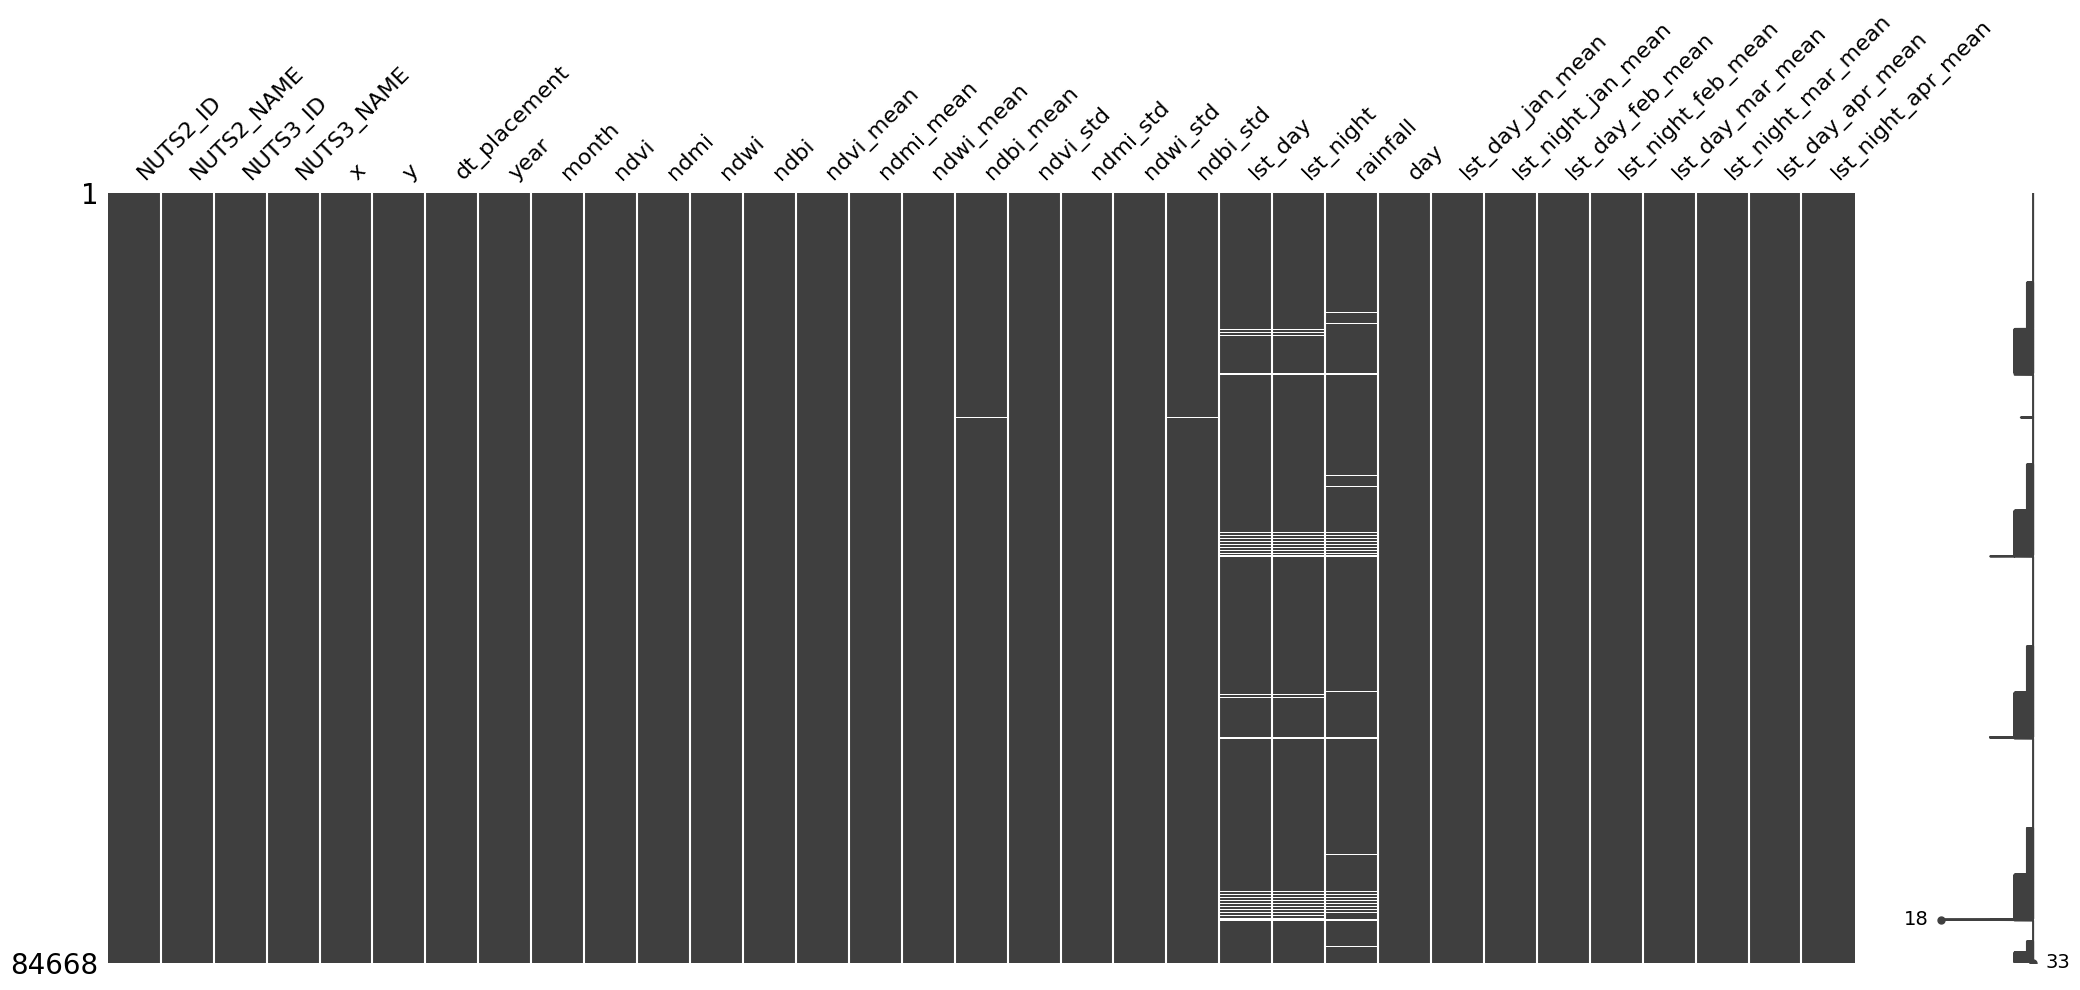

In [25]:
missingno.matrix(data_mean)

In [26]:
data_mean.to_csv(f'{base_folder}/{NUTS2}/GR_{NUTS2}_Timeline_NUTS3_{YEAR}_filled_mean.csv', encoding='utf-8')